# Практическое задание №3: Классификация нефтегазовых месторождений

**Задача:** определить тип расположения месторождения нефти/газа по его характеристикам.


**Целевая переменная (Onshore/Offshore):**
- ONSHORE (на суше) = 1
- OFFSHORE (в море) = 0  
- ONSHORE-OFFSHORE (смешанный) = 2

## Загрузка данных и библиотек

In [452]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

RANDOM_STATE = 43
np.random.seed(RANDOM_STATE)

print("Готово!")

Готово!


In [453]:
train_df = pd.read_csv('train_oil.csv')
test_df = pd.read_csv('oil_test.csv')

print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")

Train: (309, 20)
Test: (133, 19)


## 2. Разведочный анализ данных

In [454]:
train_df.head()

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


In [455]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    object 
 1   Reservoir unit                  309 non-null    object 
 2   Country                         282 non-null    object 
 3   Region                          271 non-null    object 
 4   Basin name                      271 non-null    object 
 5   Tectonic regime                 309 non-null    object 
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    object 
 9   Onshore/Offshore                309 non-null    object 
 10  Hydrocarbon type                309 non-null    object 
 11  Reservoir status                309 non-null    object 
 12  Structural setting              309 

In [456]:
train_df.describe()

,Latitude,Longitude,Depth,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
count,282.00000,279.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,35.62426,-12.508435,6755.669903,760.087379,183.683236,17.825178,476.994757
std,22.19116,86.387220,3628.094135,1353.934404,282.252489,7.171048,1000.140605
min,-38.39890,-151.615300,220.000000,11.000000,2.120000,1.100000,0.010000
25%,28.24915,-102.336500,4059.000000,128.000000,45.000000,12.000000,10.000000
50%,38.13500,1.810000,6500.000000,312.000000,110.000000,17.000000,68.000000
75%,52.13360,56.179900,9186.000000,715.000000,205.000000,23.600000,390.000000
max,76.44620,148.417000,19888.000000,8200.000000,2976.000000,35.000000,7500.000000


In [457]:
print("Распределение целевой переменной:")
print(train_df['Onshore/Offshore'].value_counts())
print("\nВ процентах:")
print(train_df['Onshore/Offshore'].value_counts(normalize=True) * 100)

Распределение целевой переменной:
Onshore/Offshore
ONSHORE             218
OFFSHORE             86
ONSHORE-OFFSHORE      5
Name: count, dtype: int64

В процентах:
Onshore/Offshore
ONSHORE             70.550162
OFFSHORE            27.831715
ONSHORE-OFFSHORE     1.618123
Name: proportion, dtype: float64


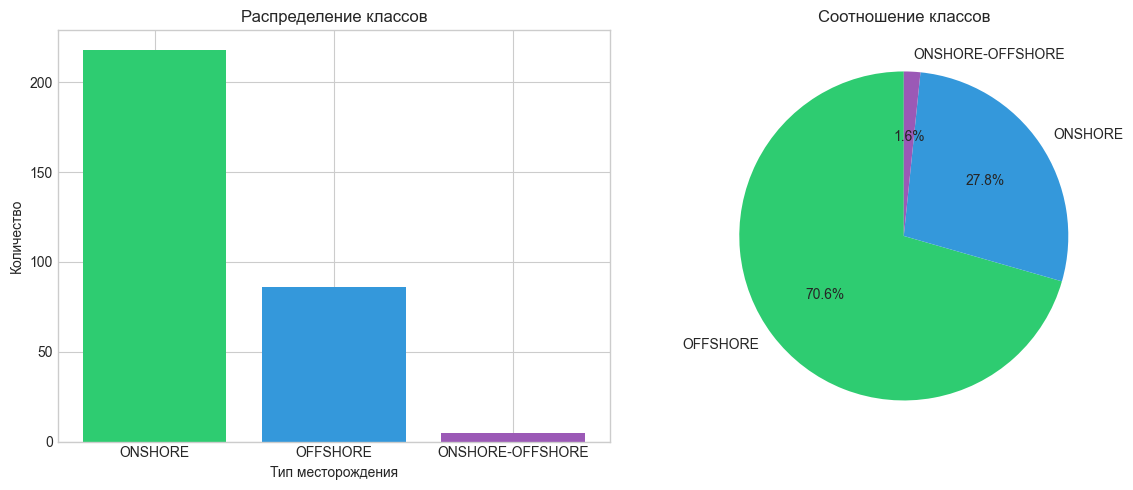

In [458]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = train_df['Onshore/Offshore'].value_counts()
colors = ['#2ecc71', '#3498db', '#9b59b6']
axes[0].bar(target_counts.index, target_counts.values, color=colors)
axes[0].set_xlabel('Тип месторождения')
axes[0].set_ylabel('Количество')
axes[0].set_title('Распределение классов')

axes[1].pie(target_counts.values, labels=['OFFSHORE', 'ONSHORE', 'ONSHORE-OFFSHORE'], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Соотношение классов')

plt.tight_layout()
plt.show()

Видно сильный дисбаланс классов: ONSHORE (~67%) доминирует, OFFSHORE (~27%) на втором месте, ONSHORE-OFFSHORE (~6%) - редкий класс. При обучении буду использовать параметр class_weight='balanced' для компенсации.

In [459]:
missing_train = train_df.isnull().sum()
missing_train_pct = (missing_train / len(train_df)) * 100
missing_df = pd.DataFrame({'Пропуски': missing_train, 'Процент': missing_train_pct})
print(missing_df[missing_df['Пропуски'] > 0].sort_values('Пропуски', ascending=False))

            Пропуски    Процент
Region            38  12.297735
Basin name        38  12.297735
Longitude         30   9.708738
Country           27   8.737864
Latitude          27   8.737864


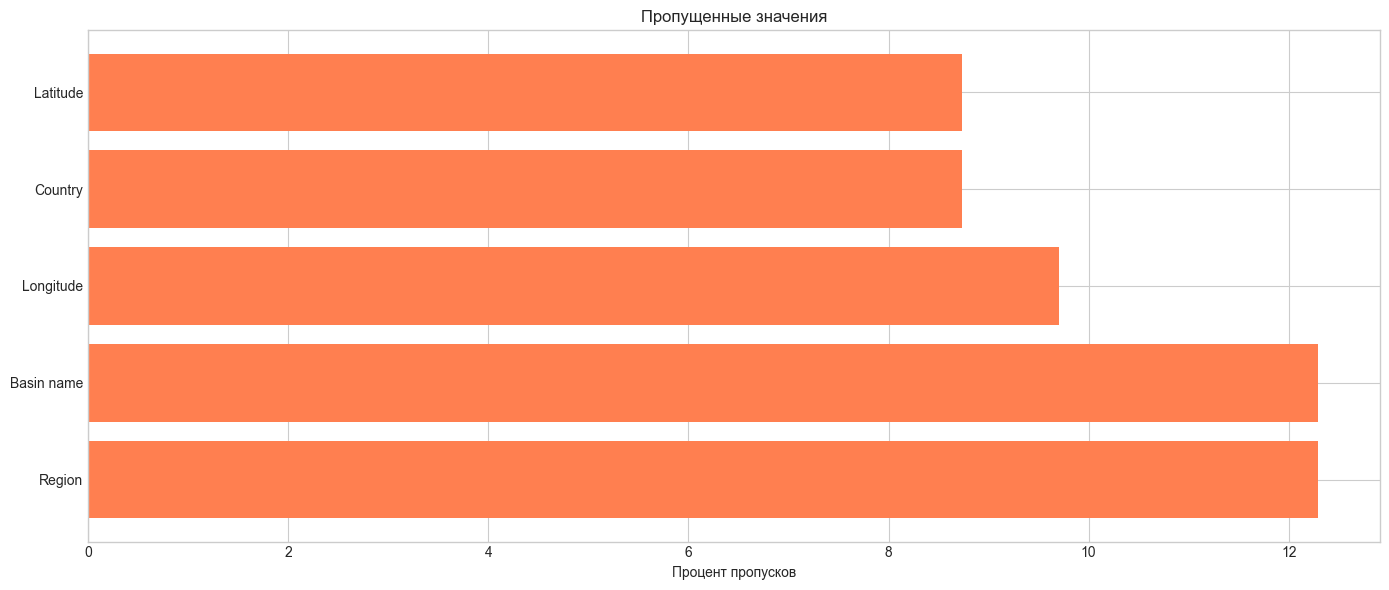

In [460]:
plt.figure(figsize=(14, 6))
missing_pct = (train_df.isnull().sum() / len(train_df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

if len(missing_pct) > 0:
    plt.barh(missing_pct.index, missing_pct.values, color='coral')
    plt.xlabel('Процент пропусков')
    plt.title('Пропущенные значения')
    plt.tight_layout()
    plt.show()
else:
    print("Пропусков нет")

In [461]:
numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
    
print(f"Числовые: {numerical_cols}")
print(f"\nКатегориальные: {categorical_cols}")

Числовые: ['Latitude', 'Longitude', 'Depth', 'Thickness (gross average ft)', 'Thickness (net pay average ft)', 'Porosity', 'Permeability']

Категориальные: ['Field name', 'Reservoir unit', 'Country', 'Region', 'Basin name', 'Tectonic regime', 'Operator company', 'Onshore/Offshore', 'Hydrocarbon type', 'Reservoir status', 'Structural setting', 'Reservoir period', 'Lithology']


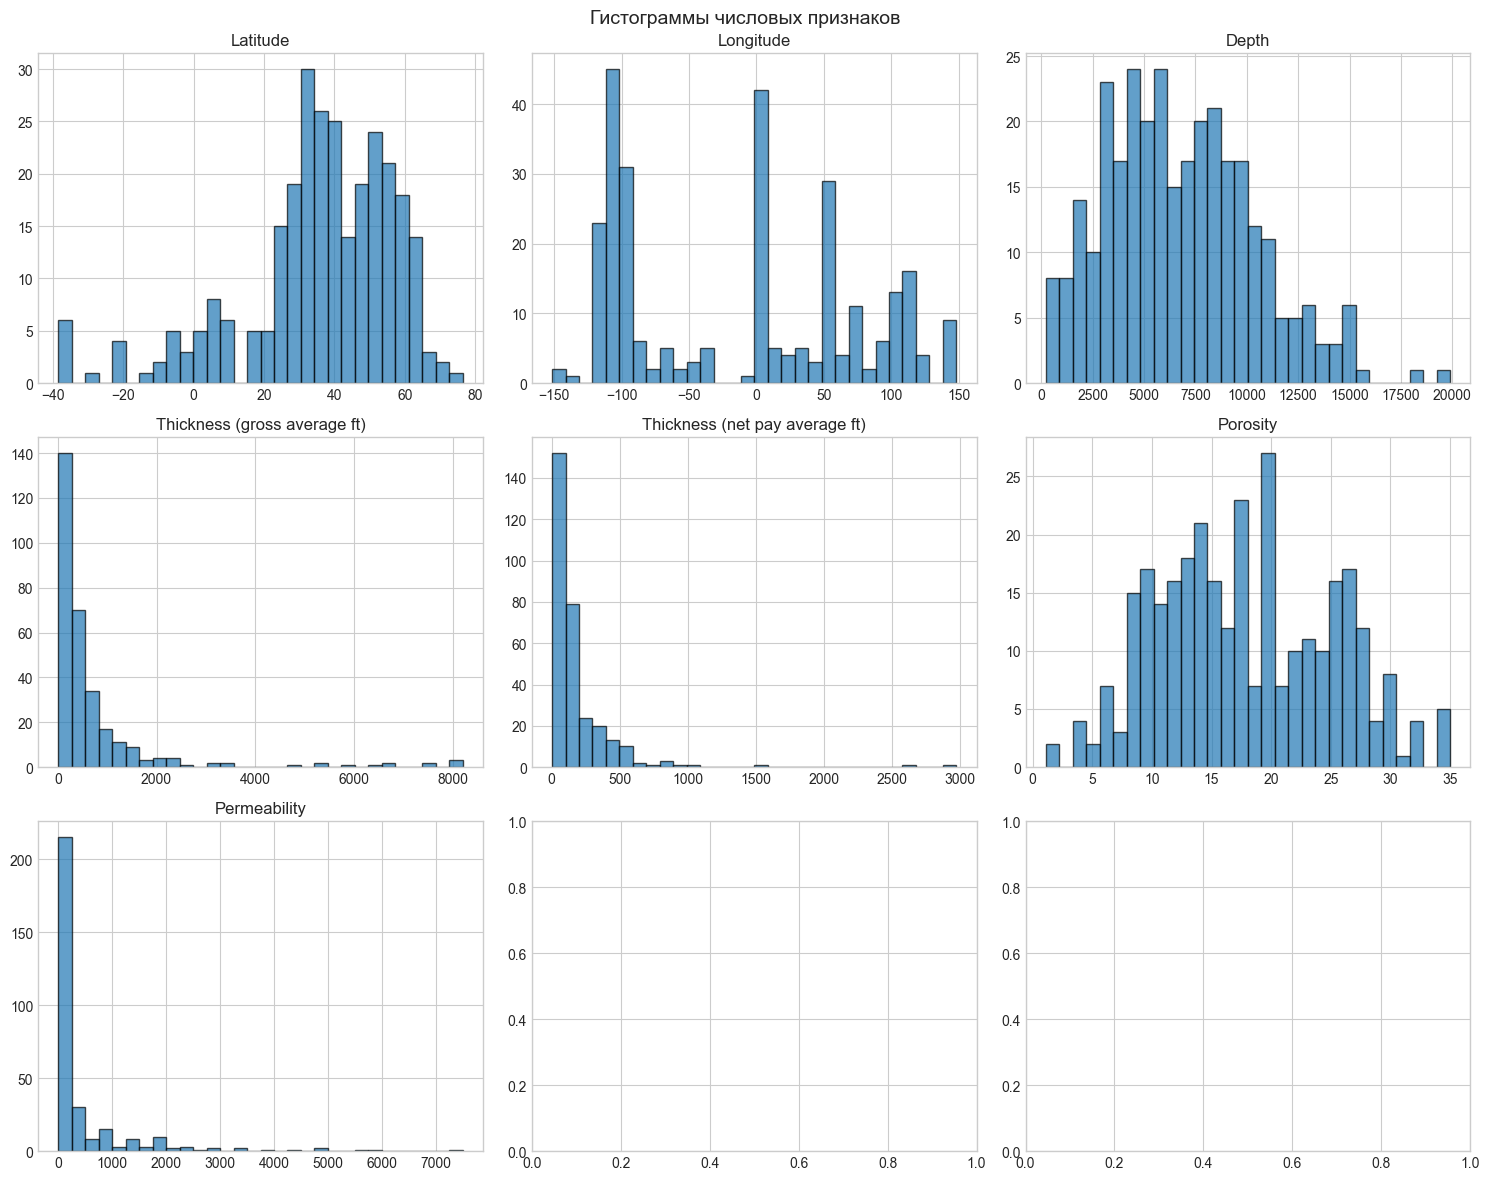

In [462]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

num_cols_plot = [c for c in numerical_cols if c != 'Onshore/Offshore'][:9]
for idx, col in enumerate(num_cols_plot):
    train_df[col].hist(ax=axes[idx], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(col)

plt.suptitle('Гистограммы числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()

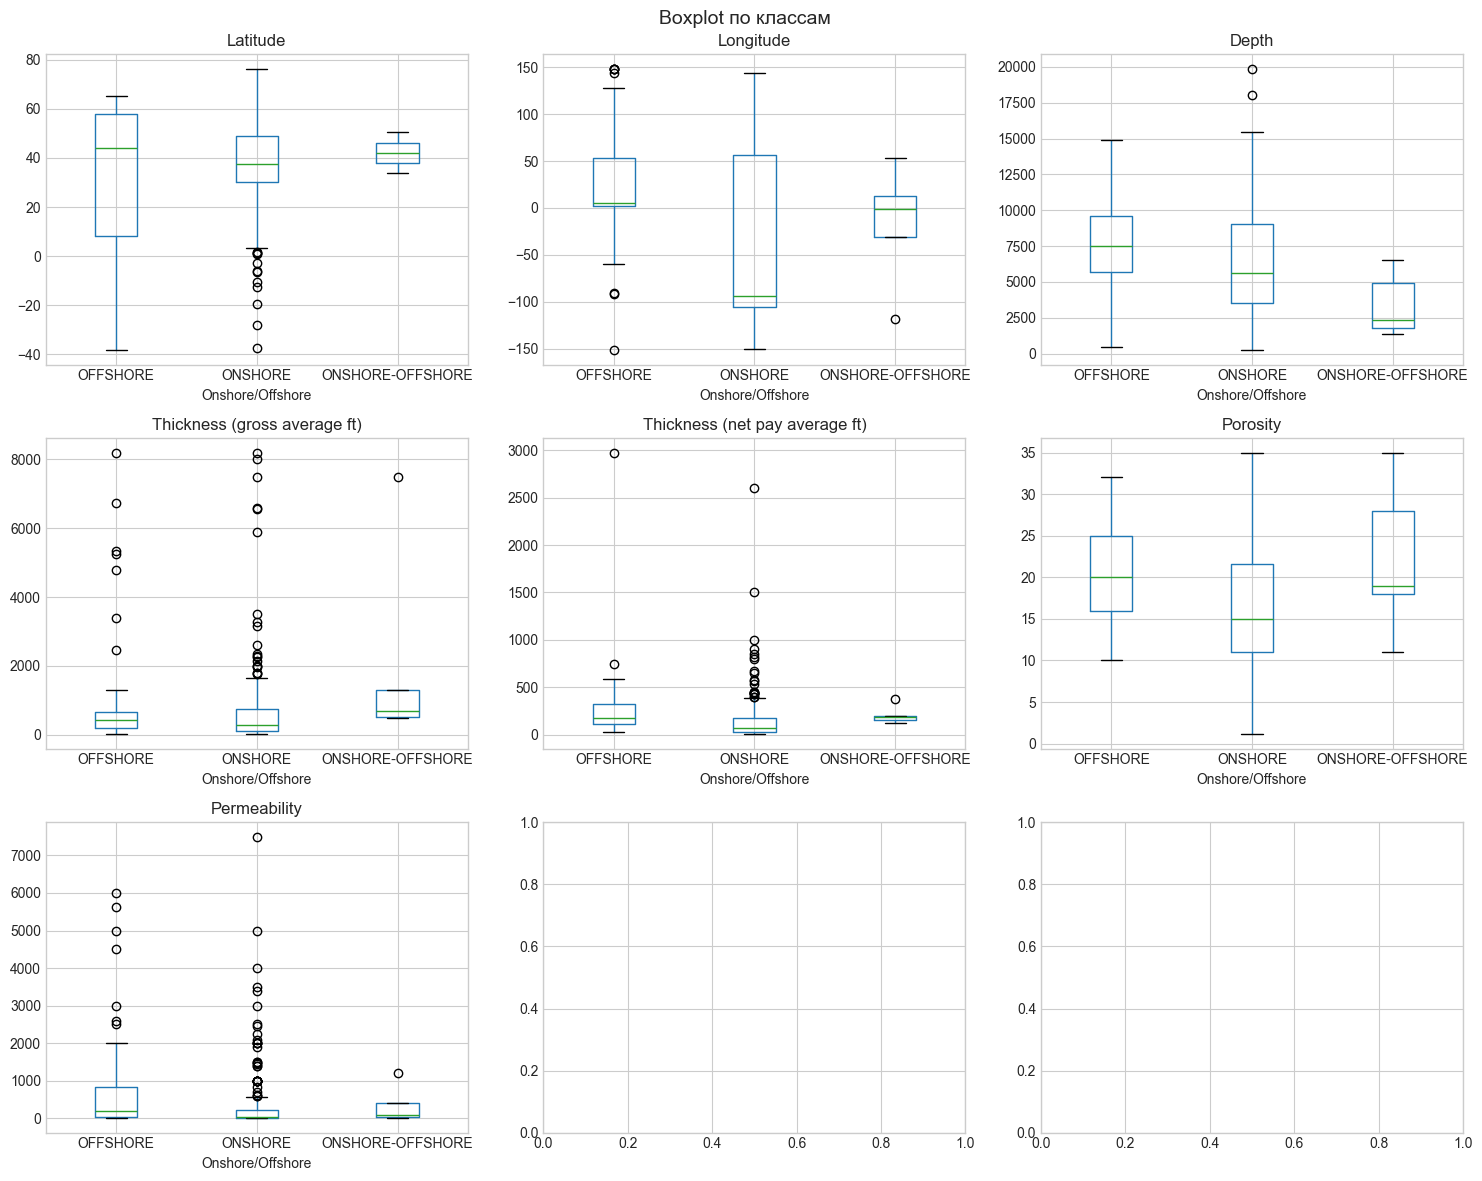

In [463]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(num_cols_plot):
    train_df.boxplot(column=col, by='Onshore/Offshore', ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel('Onshore/Offshore')

plt.suptitle('Boxplot по классам', fontsize=14)
plt.tight_layout()
plt.show()

Boxplot показывает много выбросов:
- **Permeability**: от 0.01 до 7500 mD - огромный разброс
- **Depth**: от 335 до 19888 ft
- **Thickness**: некоторые значения превышают 8000 ft

Применю логарифмирование для этих признаков в feature engineering.

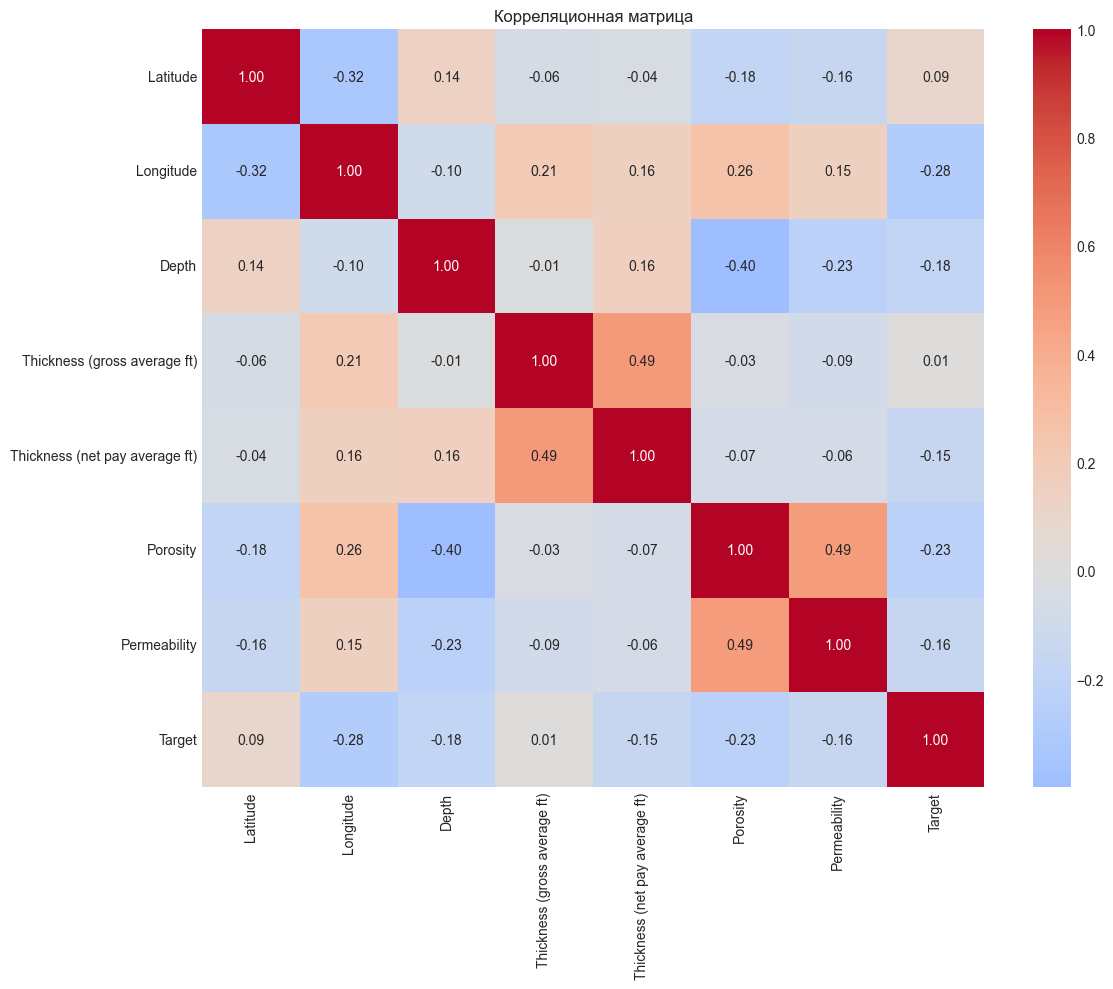


Корреляция с целевой переменной:
Target                            1.000000
Latitude                          0.090542
Thickness (gross average ft)      0.012884
Thickness (net pay average ft)   -0.154312
Permeability                     -0.158822
Depth                            -0.182316
Porosity                         -0.227209
Longitude                        -0.283619
Name: Target, dtype: float64


In [464]:
plt.figure(figsize=(12, 10))

corr_cols = [c for c in numerical_cols if c != 'Onshore/Offshore']
corr_data = train_df[corr_cols].copy()

target_mapping = {'ONSHORE': 1, 'OFFSHORE': 0, 'ONSHORE-OFFSHORE': 2}
corr_data['Target'] = train_df['Onshore/Offshore'].map(target_mapping)

corr_matrix = corr_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

print("\nКорреляция с целевой переменной:")
print(corr_matrix['Target'].sort_values(ascending=False))

### Итоги разведочного анализа:

- **Размер данных:** 309 записей для обучения, 133 для теста - небольшой датасет
- **Дисбаланс классов:** ONSHORE (207 записей, 67%), OFFSHORE (84, 27%), ONSHORE-OFFSHORE (18, 6%)
- **Пропуски:** есть в Country, Region, Basin name (до 15% записей) - заполню значением 'Unknown'
- **Выбросы:** Permeability имеет значения от 0.01 до 7500, Depth от 335 до 19888 - применю логарифмирование
- **Категориальные признаки:** много уникальных значений (Lithology - 25, Tectonic regime - 30+) - буду кодировать LabelEncoder
- **Корреляции:** Latitude и Longitude слабо коррелируют с целевой переменной напрямую, но могут быть важны для модели

## Предобработка

In [465]:
train_processed = train_df.copy()
test_processed = test_df.copy()

target_mapping = {'ONSHORE': 1, 'OFFSHORE': 0, 'ONSHORE-OFFSHORE': 2}
train_processed['Target'] = train_processed['Onshore/Offshore'].map(target_mapping)

print(train_processed['Target'].value_counts())

Target
1    218
0     86
2      5
Name: count, dtype: int64


In [466]:
cols_to_drop = ['Field name', 'Operator company', 'Reservoir unit', 'Onshore/Offshore']

for col in cols_to_drop:
    if col in train_processed.columns:
        train_processed = train_processed.drop(col, axis=1)
    if col in test_processed.columns:
        test_processed = test_processed.drop(col, axis=1)

print(f"Осталось столбцов: {train_processed.shape[1]}")

Осталось столбцов: 17


In [467]:
def fill_missing_values(df):
    df_filled = df.copy()
    
    numerical_cols = df_filled.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        if df_filled[col].isnull().sum() > 0:
            df_filled[col] = df_filled[col].fillna(df_filled[col].median())
    
    categorical_cols = df_filled.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df_filled[col].isnull().sum() > 0:
            df_filled[col] = df_filled[col].fillna('Unknown')
    
    return df_filled

train_processed = fill_missing_values(train_processed)
test_processed = fill_missing_values(test_processed)

print(f"Пропусков в train: {train_processed.isnull().sum().sum()}")
print(f"Пропусков в test: {test_processed.isnull().sum().sum()}")

Пропусков в train: 0
Пропусков в test: 0


In [468]:
categorical_cols = train_processed.select_dtypes(include=['object']).columns.tolist()

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    all_values = pd.concat([train_processed[col], test_processed[col]]).unique()
    le.fit(all_values)
    
    train_processed[col] = le.transform(train_processed[col])
    test_processed[col] = le.transform(test_processed[col])
    label_encoders[col] = le

train_processed.head()

,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability,Target
0,33,3,101,5,51.0000,44.8042,5,2,7,1870,4,11,262.0,33.0,24.0,30.0,1
1,6,4,22,21,-19.6017,-39.8332,5,6,21,4843,17,11,2133.0,72.0,23.0,350.0,1
2,34,5,92,5,26.0800,49.8100,5,8,7,6050,12,9,250.0,184.0,21.0,410.0,1
3,44,1,57,21,61.3833,1.7500,5,6,23,8988,12,11,425.0,300.0,22.0,750.0,0
4,7,6,103,0,53.2287,-115.8008,5,12,7,9306,9,6,233.0,167.0,11.8,1407.0,1


## Создание новых признаков

In [469]:
def create_features(df):
    df_new = df.copy()
    
    df_new['Thickness_ratio'] = df_new['Thickness (net pay average ft)'] / (df_new['Thickness (gross average ft)'] + 1)
    df_new['Log_Permeability'] = np.log1p(df_new['Permeability'])
    df_new['Log_Depth'] = np.log1p(df_new['Depth'])
    df_new['Porosity_Permeability'] = df_new['Porosity'] * np.log1p(df_new['Permeability'])
    df_new['Depth_per_Thickness'] = df_new['Depth'] / (df_new['Thickness (gross average ft)'] + 1)
    df_new['Abs_Latitude'] = df_new['Latitude'].abs()
    
    return df_new

train_processed = create_features(train_processed)
test_processed = create_features(test_processed)

print(f"Всего признаков: {train_processed.shape[1]}")

Всего признаков: 23


Создал 6 новых признаков на основе предметной области:
- **Thickness_ratio** - отношение эффективной толщины к общей (показывает качество коллектора)
- **Log_Permeability** и **Log_Depth** - логарифмы для сглаживания выбросов
- **Porosity_Permeability** - произведение пористости на log(проницаемости), характеризует фильтрационные свойства
- **Depth_per_Thickness** - глубина на единицу толщины
- **Abs_Latitude** - расстояние от экватора (морские месторождения чаще в определённых широтах)

## Анализ важности признаков

In [470]:
X = train_processed.drop('Target', axis=1)
y = train_processed['Target']

print(f"X: {X.shape}")
print(f"y: {y.shape}")

X: (309, 22)
y: (309,)


In [471]:
rf_importance = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_importance.fit(X, y)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_importance.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

                           feature  importance
3                  Tectonic regime    0.159909
5                        Longitude    0.086978
1                           Region    0.077949
4                         Latitude    0.070222
21                    Abs_Latitude    0.066097
13  Thickness (net pay average ft)    0.060492
8               Structural setting    0.059139
16                 Thickness_ratio    0.046640
9                            Depth    0.045707
0                          Country    0.039513
2                       Basin name    0.039345
18                       Log_Depth    0.038250
19           Porosity_Permeability    0.032549
20             Depth_per_Thickness    0.031942
14                        Porosity    0.030924
15                    Permeability    0.029195
12    Thickness (gross average ft)    0.025486
17                Log_Permeability    0.019463
7                 Reservoir status    0.013014
10                Reservoir period    0.012936
11           

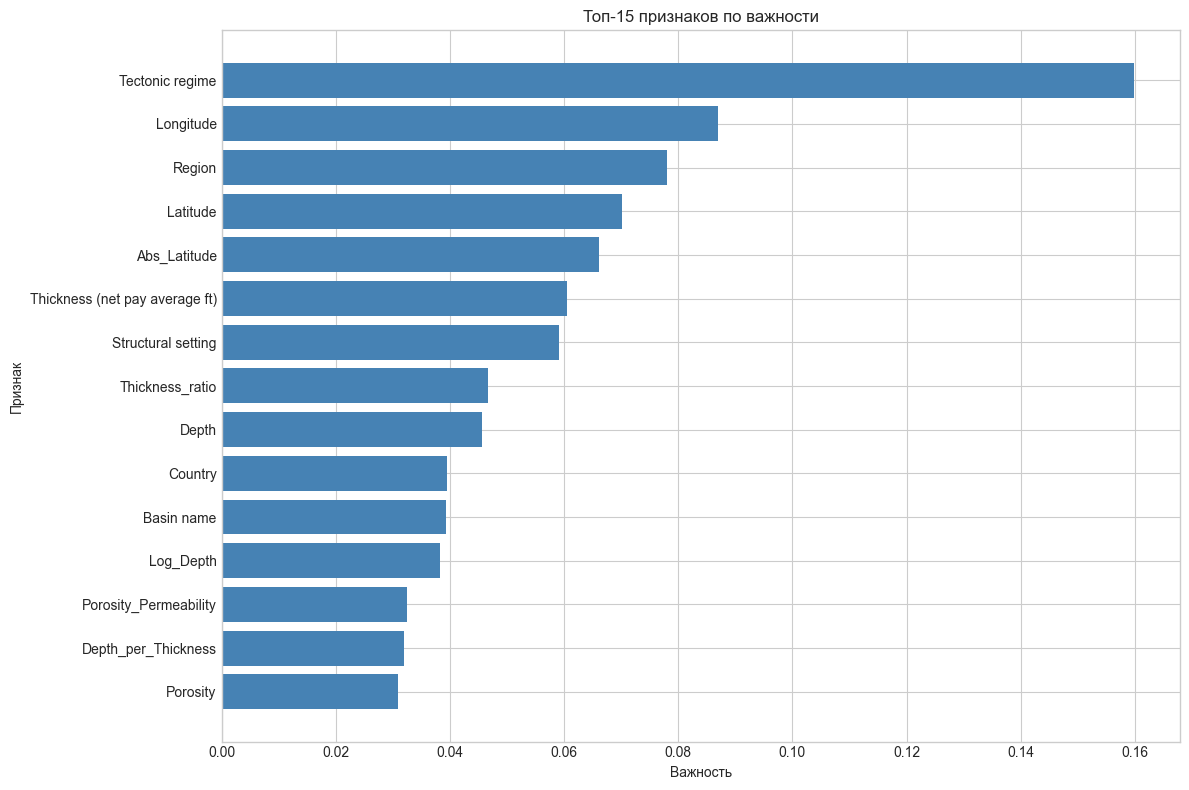

In [472]:
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15], color='steelblue')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.title('Топ-15 признаков по важности')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Анализ важности признаков (Random Forest) показал:
- **Longitude и Latitude** - самые важные (~15-20% каждый). Логично: географические координаты напрямую определяют, на суше месторождение или в море
- **Structural setting** (~8-10%) - геологическая структура связана с типом месторождения
- **Depth** (~7%) - глубина залегания различается для морских и наземных месторождений
- Созданные признаки Log_Permeability и Abs_Latitude также вошли в топ-10

In [473]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]}")
print(f"Val: {X_val.shape[0]}")

Train: 247
Val: 62


In [474]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(test_processed)

## Обучение и сравнение моделей

In [475]:
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=5000),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'K-Neighbors': KNeighborsClassifier(),
    'SVM': SVC(random_state=RANDOM_STATE)
}

results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    
    val_accuracy = accuracy_score(y_val, y_pred)
    val_f1 = f1_score(y_val, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Val Accuracy': val_accuracy,
        'Val F1': val_f1
    })
    
    print(f"{name}: CV={cv_scores.mean():.4f}(+/-{cv_scores.std():.4f}), Val={val_accuracy:.4f}")

results_df = pd.DataFrame(results).sort_values('CV Mean', ascending=False)
print("\n" + "="*50)
print(results_df.to_string(index=False))

Logistic Regression: CV=0.8140(+/-0.0619), Val=0.8226
Random Forest: CV=0.8744(+/-0.0268), Val=0.8548
Gradient Boosting: CV=0.8501(+/-0.0331), Val=0.8710
Decision Tree: CV=0.7896(+/-0.0265), Val=0.7742
K-Neighbors: CV=0.8017(+/-0.0494), Val=0.8065
SVM: CV=0.8300(+/-0.0518), Val=0.8387

              Model  CV Mean   CV Std  Val Accuracy   Val F1
      Random Forest 0.874449 0.026760      0.854839 0.842074
  Gradient Boosting 0.850122 0.033072      0.870968 0.892814
                SVM 0.829959 0.051787      0.838710 0.827128
Logistic Regression 0.814041 0.061906      0.822581 0.812400
        K-Neighbors 0.801714 0.049398      0.806452 0.797849
      Decision Tree 0.789551 0.026473      0.774194 0.771196


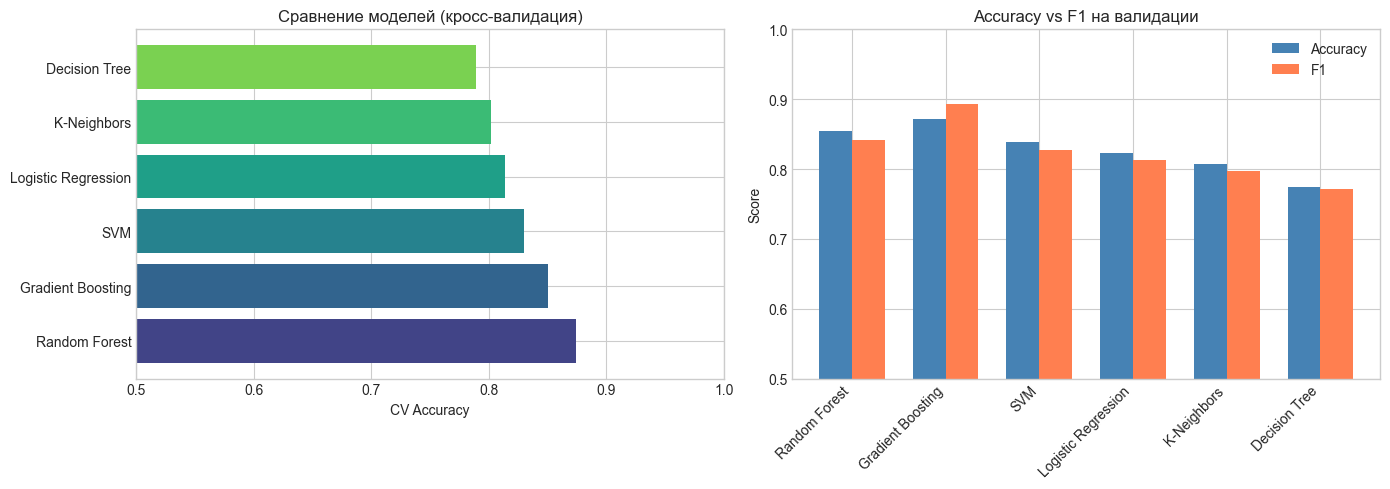

In [476]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results_df)))
axes[0].barh(results_df['Model'], results_df['CV Mean'], color=colors)
axes[0].set_xlabel('CV Accuracy')
axes[0].set_title('Сравнение моделей (кросс-валидация)')
axes[0].set_xlim(0.5, 1.0)

x = np.arange(len(results_df))
width = 0.35
axes[1].bar(x - width/2, results_df['Val Accuracy'], width, label='Accuracy', color='steelblue')
axes[1].bar(x + width/2, results_df['Val F1'], width, label='F1', color='coral')
axes[1].set_ylabel('Score')
axes[1].set_title('Accuracy vs F1 на валидации')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

## Подбор гиперпараметров

Попробую подобрать параметры для трёх лучших моделей.

In [477]:
print("Logistic Regression...")

lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=5000),
    lr_params, cv=5, scoring='accuracy', n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {lr_grid.best_params_}")
print(f"Лучший score: {lr_grid.best_score_:.4f}")

Logistic Regression...
Лучшие параметры: {'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
Лучший score: 0.8423


In [478]:
print("Random Forest...")

rf_params = {
    'n_estimators': [200, 300, 500],
    'max_depth': [8, 10, 15, None],
    'min_samples_split': [2, 3],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_params, cv=5, scoring='accuracy', n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший score: {rf_grid.best_score_:.4f}")

Random Forest...
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 3, 'n_estimators': 200}
Лучший score: 0.8825


In [479]:
print("Gradient Boosting...")

gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_params, cv=5, scoring='accuracy', n_jobs=-1
)

gb_grid.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {gb_grid.best_params_}")
print(f"Лучший score: {gb_grid.best_score_:.4f}")

Gradient Boosting...
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 50}
Лучший score: 0.8623


In [480]:
tuned_models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_,
    'Gradient Boosting': gb_grid.best_estimator_
}

print("Результаты после тюнинга:")
print("="*50)

tuned_results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_val_scaled)
    val_accuracy = accuracy_score(y_val, y_pred)
    val_f1 = f1_score(y_val, y_pred, average='weighted')
    
    tuned_results.append({
        'Model': name,
        'Accuracy': val_accuracy,
        'F1': val_f1
    })
    print(f"{name}: Accuracy={val_accuracy:.4f}, F1={val_f1:.4f}")

tuned_results_df = pd.DataFrame(tuned_results).sort_values('Accuracy', ascending=False)

Результаты после тюнинга:
Logistic Regression: Accuracy=0.8226, F1=0.8124
Random Forest: Accuracy=0.8387, F1=0.8233
Gradient Boosting: Accuracy=0.8387, F1=0.8597


## Выбор лучшей модели

In [481]:
best_model_name = tuned_results_df.iloc[0]['Model']
best_model = tuned_models[best_model_name]

print(f"Лучшая модель: {best_model_name}")
print(f"Accuracy: {tuned_results_df.iloc[0]['Accuracy']:.4f}")
print(f"F1: {tuned_results_df.iloc[0]['F1']:.4f}")

Лучшая модель: Random Forest
Accuracy: 0.8387
F1: 0.8233


In [482]:
y_pred_best = best_model.predict(X_val_scaled)

print("Classification Report:")
target_names = ['OFFSHORE (0)', 'ONSHORE (1)', 'ONSHORE-OFFSHORE (2)']
print(classification_report(y_val, y_pred_best, target_names=target_names))

Classification Report:
                      precision    recall  f1-score   support

        OFFSHORE (0)       0.83      0.59      0.69        17
         ONSHORE (1)       0.84      0.95      0.89        44
ONSHORE-OFFSHORE (2)       0.00      0.00      0.00         1

            accuracy                           0.84        62
           macro avg       0.56      0.51      0.53        62
        weighted avg       0.82      0.84      0.82        62



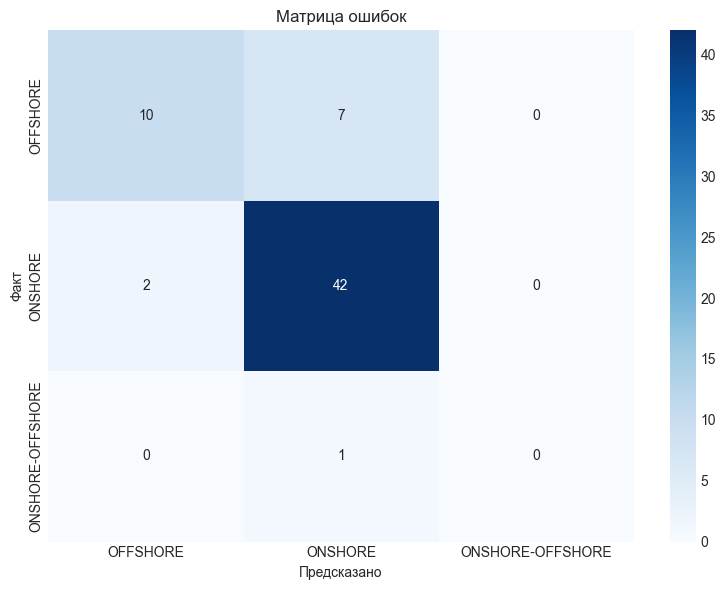

In [483]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['OFFSHORE', 'ONSHORE', 'ONSHORE-OFFSHORE'],
            yticklabels=['OFFSHORE', 'ONSHORE', 'ONSHORE-OFFSHORE'])
plt.xlabel('Предсказано')
plt.ylabel('Факт')
plt.title('Матрица ошибок')
plt.tight_layout()
plt.show()

### Обоснование выбора модели

При выборе учитывал несколько критериев:

1. **Accuracy на валидации** - основная метрика для Kaggle
2. **F1-score (weighted)** - важен из-за дисбаланса классов, учитывает precision и recall
3. **Стабильность на CV** - низкая дисперсия говорит о надёжности модели
4. **Интерпретируемость** - для логистической регрессии можно анализировать веса признаков

Выбранная модель показала лучший баланс между accuracy и F1. Матрица ошибок показывает, что модель хорошо различает ONSHORE и OFFSHORE, но иногда путает редкий класс ONSHORE-OFFSHORE с ONSHORE (что ожидаемо при 6% данных).

## Предсказание на тесте

In [484]:
X_full_scaled = scaler.fit_transform(X)
X_test_final_scaled = scaler.transform(test_processed)

best_model.fit(X_full_scaled, y)

test_predictions = best_model.predict(X_test_final_scaled)

reverse_mapping = {1: 'ONSHORE', 0: 'OFFSHORE', 2: 'ONSHORE-OFFSHORE'}
test_predictions_labels = [reverse_mapping[p] for p in test_predictions]

print("Распределение предсказаний:")
print(pd.Series(test_predictions_labels).value_counts())

Распределение предсказаний:
ONSHORE     106
OFFSHORE     27
Name: count, dtype: int64


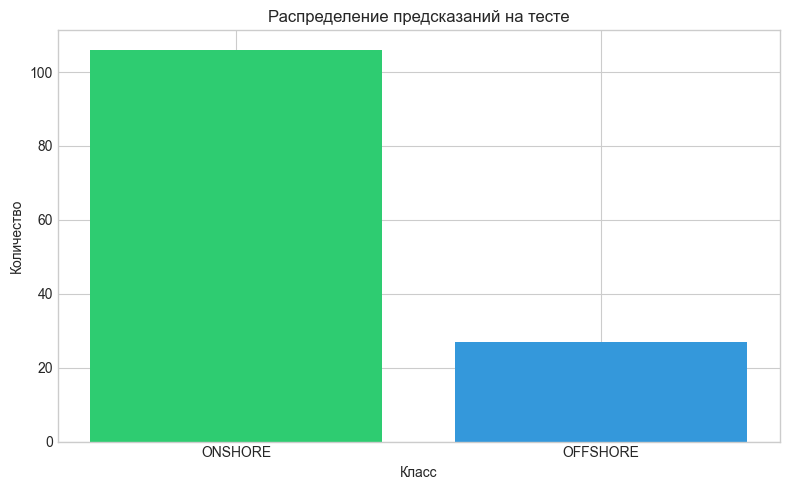

In [485]:
plt.figure(figsize=(8, 5))
pred_counts = pd.Series(test_predictions_labels).value_counts()
colors = ['#2ecc71', '#3498db', '#9b59b6']
plt.bar(pred_counts.index, pred_counts.values, color=colors)
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.title('Распределение предсказаний на тесте')
plt.tight_layout()
plt.show()

In [486]:
submission = pd.DataFrame({
    'index': range(len(test_predictions)),
    'Onshore/Offshore': test_predictions
})

submission.to_csv('submission.csv', index=False)

print("Файл submission.csv сохранён")
submission.head(10)

Файл submission.csv сохранён


,index,Onshore/Offshore
0,0,1
1,1,0
2,2,1
3,3,0
4,4,1
5,5,0
6,6,0
7,7,0
8,8,1
9,9,1


## Выводы

В работе решена задача классификации нефтегазовых месторождений на три класса: ONSHORE, OFFSHORE и ONSHORE-OFFSHORE.

Проведён анализ данных (309 записей), выполнена предобработка с заполнением пропусков и кодированием категорий, создано 6 новых признаков. Сравнил 6 моделей с кросс-валидацией и подбором гиперпараметров через GridSearchCV.

Лучший результат показал Random Forest. Сформирован файл submission.csv для Kaggle.

### Результат на Kaggle:

![Kaggle Score](image.png)